### __Predicting Airbnb Listing Prices in Sydney__

--- 
## Task 3: Feature Engineering


### Steps to select the best features from the dataset

Feature Engineering is essential to improve regression model performance. This task focuses on feature selection, which helps in reducing dimensionality and improving model performance by keeping only the most relevant features. Since some features have low correlation or importance, we should refine our feature selection process. Here’s the approach we should take:

**1️. Use Only Highly Correlated Features**
- Select features that have a strong correlation (e.g., `|correlation| > 0.2`) with `price`.
- Drop weakly correlated features (like most of the date-based ones).

**2. Remove Multicollinearity**
- If two features are highly correlated with each other (e.g., `bedrooms` and `beds`), keep only one.
- This prevents redundant information in the model.

In [107]:
# Import required libraries
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_selection import mutual_info_regression

In [108]:
# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

# Configure seaborn aesthetics
sns.set(style="whitegrid", palette="muted", font_scale=1.2)

Firstly, we import the processed data from the completed data cleaning step: 

In [109]:
# Import both the training and testing data
df_train = pd.read_csv(r"C:\Users\haiho\GITHUB\Sydney-Airbnb-prices-prediction\data\processed\processed_train.csv")
df_test = pd.read_csv(r"C:\Users\haiho\GITHUB\Sydney-Airbnb-prices-prediction\data\processed\processed_test.csv")

In [110]:
# Define a list of DataFrames for repeated uses
dfs = [df_train, df_test]

### 1. Use Only Highly Correlated Features

To explore and measure the relationship between current features and `price` as the target variable, we can construct correlation matrix to establish them.

There still exists some text-based columns which are too general and irrelevant for predict price, we will drop them before executing the correlation matrix. 

In [111]:
df_train.columns

Index(['host_name', 'host_since', 'host_location', 'host_response_rate',
       'host_acceptance_rate', 'host_is_superhost', 'host_listings_count',
       'host_has_profile_pic', 'host_identity_verified', 'accommodates',
       'bedrooms', 'beds', 'minimum_nights', 'maximum_nights',
       'minimum_minimum_nights', 'maximum_minimum_nights',
       'minimum_maximum_nights', 'maximum_maximum_nights',
       'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'has_availability',
       'availability_30', 'availability_60', 'availability_90',
       'availability_365', 'number_of_reviews', 'number_of_reviews_ltm',
       'number_of_reviews_l30d', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value', 'instant_bookable',
       'calculated_host_listings_count',
       'calculated_host_listings_count_entire_homes',
       'calculated_host_listi

In [112]:
# Exclude object columns
df_train = df_train.select_dtypes(exclude=['object'])

In [113]:
# Correlation Analysis
correlation_matrix = df_train.corr()
price_correlations = correlation_matrix["price"].sort_values(ascending=False)
price_correlations

price                   1.000000
price_per_bedroom       0.892481
bedrooms                0.654258
accommodates            0.597608
beds                    0.531221
                          ...   
reviews_per_month      -0.112386
number_of_reviews      -0.117206
response_time          -0.130608
host_acceptance_rate   -0.151383
mapped_bathrooms       -0.304940
Name: price, Length: 55, dtype: float64

In [114]:
# Examine the distribution of correlation values
price_correlations.describe()

count    55.000000
mean      0.064121
std       0.244253
min      -0.304940
25%      -0.074587
50%      -0.001512
75%       0.073358
max       1.000000
Name: price, dtype: float64

A heatmap of the feature correlation matrix would describe the relationship between predictor features and `price` better through visualization.

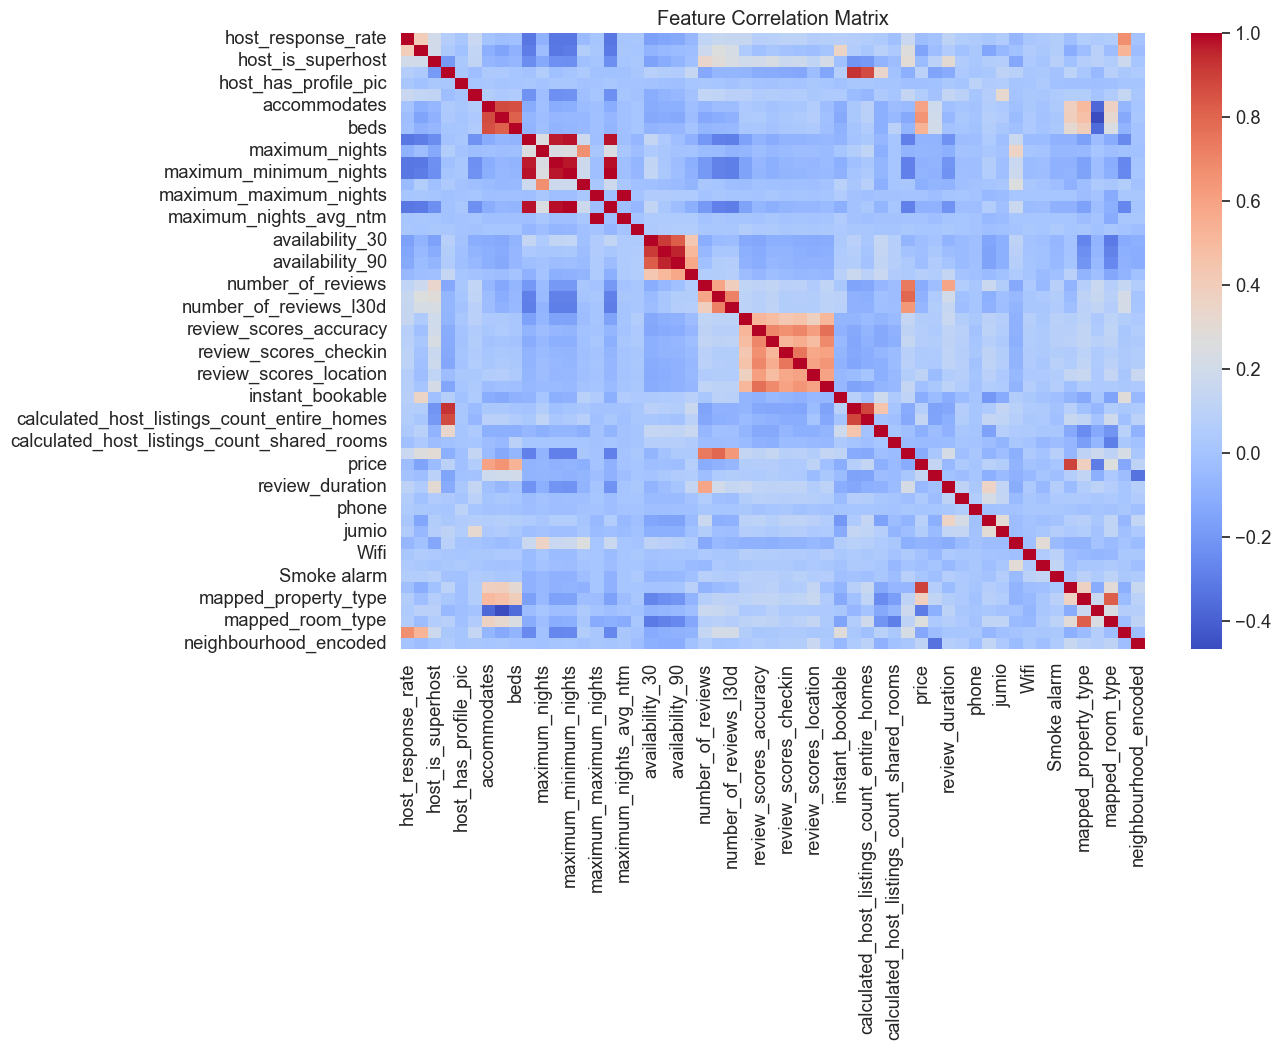

In [115]:
# Visualize the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(df_train.corr(), annot=False, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

After cleaning all features including filling missing values, tranforming data types, more numeric features are added to the correlation matrix for better evaluation before the modelling step. However, we only want to retrieve features with moderate and strong correlation.

Features with **very low correlation (< 0.2)** contribute little to linear models and may introduce noise. And if we set the threshold **too high (e.g., 0.5 or 0.7)**, we may miss important features that contribute slightly but collectively improve the model. Therefore, based on the correlation matrix output, a threshold of 0.2 is suitable.

In [116]:
# Define a correlation threshold
corr_threshold = 0.2

In [117]:
# Select features with correlation > threshold (excluding 'price' itself)
selected_features_corr = price_correlations[abs(price_correlations) > corr_threshold].index.tolist()
selected_features_corr.remove("price")  # Remove target variable
selected_features_corr

['price_per_bedroom',
 'bedrooms',
 'accommodates',
 'beds',
 'mapped_property_type',
 'mapped_room_type',
 'mapped_bathrooms']

### 2. Remove Features with Mutual Information

In current situation of both datasets, there exist features with significant mutual information that will cause redundancy and irrelevance: 
- `neighbourhood_cleansed` and `neighbourhood` likely contain similar information.
- `host_location` may not be necessary if it's the same as `neighbourhood`.

In [118]:
# Create subsets of features
X = df_train.drop(columns=["price"])
y = df_train["price"]

In [119]:
# Compute mutual information scores for feature selection
mutual_info = mutual_info_regression(X, y)
mutual_info_series = pd.Series(mutual_info, index=X.columns)

Examining how `mutual_info_series` is istributed and statistically examined will help to decide a suitable threshold to limit only features with highly mutual information.

In [120]:
# Print the mutual information scores
mutual_info_series.sort_values(ascending=False)

price_per_bedroom                              4.210694
accommodates                                   0.378736
calculated_host_listings_count_entire_homes    0.358274
mapped_property_type                           0.344111
bedrooms                                       0.343209
                                                 ...   
host_is_superhost                              0.004986
host_has_profile_pic                           0.000230
phone                                          0.000000
Essentials                                     0.000000
has_availability                               0.000000
Length: 54, dtype: float64

In [121]:
# Examine the distribution of mutual information scores
mutual_info_series.describe()

count    54.000000
mean      0.177881
std       0.569642
min       0.000000
25%       0.024254
50%       0.056753
75%       0.158894
max       4.210694
dtype: float64

As Mutual information (MI) captures **non-linear relationships** unlike correlation, MI values are often much **smaller than correlation values**, so a **lower threshold** is reasonable.

Even a small MI value of 0.02 can still indicate that a feature has some useful contribution.

In [122]:
# Set a reasonable threshold
mi_threshold = 0.02 

In [123]:
# Filter features with significant mutual information
selected_features_mi = mutual_info_series[mutual_info_series > mi_threshold].index.tolist()
selected_features_mi

['host_response_rate',
 'host_acceptance_rate',
 'host_listings_count',
 'host_identity_verified',
 'accommodates',
 'bedrooms',
 'beds',
 'minimum_nights',
 'maximum_nights',
 'minimum_minimum_nights',
 'maximum_minimum_nights',
 'minimum_maximum_nights',
 'maximum_maximum_nights',
 'minimum_nights_avg_ntm',
 'maximum_nights_avg_ntm',
 'availability_30',
 'availability_60',
 'availability_90',
 'availability_365',
 'number_of_reviews',
 'number_of_reviews_ltm',
 'review_scores_rating',
 'review_scores_accuracy',
 'review_scores_cleanliness',
 'review_scores_checkin',
 'review_scores_communication',
 'review_scores_location',
 'review_scores_value',
 'calculated_host_listings_count',
 'calculated_host_listings_count_entire_homes',
 'calculated_host_listings_count_private_rooms',
 'calculated_host_listings_count_shared_rooms',
 'reviews_per_month',
 'distance_to_city_center',
 'review_duration',
 'price_per_bedroom',
 'mapped_property_type',
 'mapped_bathrooms',
 'mapped_room_type',
 'r

Final feature selection: keep features that pass either correlation or mutual info filtering

In [124]:
# Final list of selected features (intersection of correlation and mutual information)
final_selected_features = list(set(selected_features_corr) & set(selected_features_mi))

# Display the final list of selected features
print(final_selected_features)

['mapped_room_type', 'mapped_bathrooms', 'price_per_bedroom', 'mapped_property_type', 'bedrooms', 'beds', 'accommodates']


In [125]:
print("Exact match check:", "price_per_bedroom" in final_selected_features)
print("List contents:", final_selected_features)

Exact match check: True
List contents: ['mapped_room_type', 'mapped_bathrooms', 'price_per_bedroom', 'mapped_property_type', 'bedrooms', 'beds', 'accommodates']


Now that we have chosen the best subset of features from the original dataframe, we can create new dataframes to store only entries of the selected features only: 

In [126]:
# Drop weak features from the training DataFrame
df_train_selected = df_train[final_selected_features + ["price"]]

# Drop weak features from the testing DataFrame
final_selected_features.remove("price_per_bedroom")
df_test_selected = df_test[final_selected_features]

### 3. Save Feature-Engineered Data

In [127]:
# Save the updated dataset with feature-engineered columns
df_train_selected.to_csv("C:/Users/haiho/GITHUB/Sydney-Airbnb-prices-prediction/data/processed/feature_engineered_train.csv", index=False)
df_test_selected.to_csv("C:/Users/haiho/GITHUB/Sydney-Airbnb-prices-prediction/data/processed/feature_engineered_test.csv", index=False)

Let's check again top rows of both refined DataFrames after data cleaning and feature engineering tasks:

In [128]:
df_train_selected.head()

,mapped_room_type,mapped_bathrooms,price_per_bedroom,mapped_property_type,bedrooms,beds,accommodates,price
0,4,3,117.500000,5,3,3,6,470.0
1,3,5,41.000000,2,1,1,2,82.0
2,4,6,75.000000,5,1,1,4,150.0
3,4,6,81.666667,4,2,2,4,245.0
4,3,2,29.666667,2,2,3,4,89.0


In [129]:
df_test_selected.head()

,mapped_room_type,mapped_bathrooms,mapped_property_type,bedrooms,beds,accommodates
0,3,4,2,1,1,2
1,4,6,5,1,2,2
2,4,6,5,2,2,4
3,3,6,2,1,2,4
4,3,4,2,1,2,1
